In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wavfile
import scipy.signal as signal
import soundfile as sf
from scipy.fft import fft, fftfreq
import librosa
import noisereduce as nr
import speech_recognition as sr
import vosk
import json
import os
import warnings
warnings.filterwarnings('ignore')
from typing import Tuple
import numpy as np
import librosa, os

In [2]:
def load_or_generate_signal(file_path: str = "exam-3-input.wav",
                            duration: float = 3.0,
                            sample_rate: int = 44100) -> Tuple[np.ndarray, int]:
    if file_path and os.path.exists(file_path):
        sig, sr_load = sf.read(file_path)  # preserve file's sr
        # If stereo, convert to mono
        if sig.ndim > 1:
            sig = np.mean(sig, axis=1)
        # Normalize to -1..1 if needed
        if np.max(np.abs(sig)) > 0:
            sig = sig / np.max(np.abs(sig))
        print(f"Loaded {file_path}: sample_rate={sr_load}, duration={len(sig)/sr_load:.2f}s, shape={sig.shape}")
        return sig.astype(np.float32), int(sr_load)

    # Fallback: generate synthetic speech-like signal
    print(f"{file_path} not found — generating synthetic signal instead.")
    sr_load = sample_rate
    t = np.linspace(0, duration, int(sr_load * duration), endpoint=False)
    f1, f2, f3 = 500, 1500, 2500
    f0 = 120
    components = []
    for h in range(1, 9):
        freq = f0 * h
        amp = np.exp(-((freq - f1)**2 / (2*200**2))
                     -((freq - f2)**2 / (2*300**2))
                     -((freq - f3)**2 / (2*400**2)))
        if amp > 0.005:
            components.append(amp * np.sin(2*np.pi*freq*t))
    sig = np.sum(components, axis=0)
    envelope = 0.5 * (1 + np.sin(2 * np.pi * 4 * t))
    sig *= envelope
    sig += 0.05 * np.random.normal(0, 1, len(t))
    sig = sig / np.max(np.abs(sig))
    print(f"Generated synthetic signal: sample_rate={sr_load}, duration={duration:.2f}s")
    return sig.astype(np.float32), sr_load

# Run load
original_signal, sample_rate = load_or_generate_signal("exam-3-input.wav")


Loaded exam-3-input.wav: sample_rate=44100, duration=4.15s, shape=(183015,)


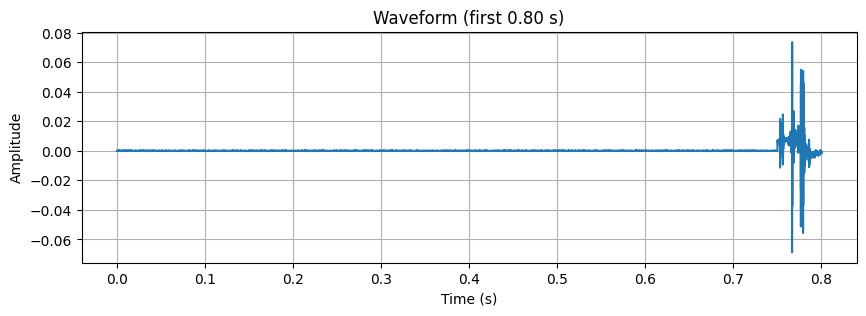

In [10]:
from IPython.display import Audio, display

# Plot short waveform (first 0.5s or entire if shorter)
def plot_waveform(sig, sr, max_seconds=0.5):
    t = np.arange(len(sig)) / sr
    end_idx = min(len(sig), int(sr * max_seconds))
    plt.figure(figsize=(10,3))
    plt.plot(t[:end_idx], sig[:end_idx])
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Waveform (first {:.2f} s)".format(min(max_seconds, len(sig)/sr)))
    plt.grid(True)
    plt.show()

plot_waveform(original_signal, sample_rate, max_seconds=0.8)

# Provide audio player
display(Audio(original_signal, rate=sample_rate))


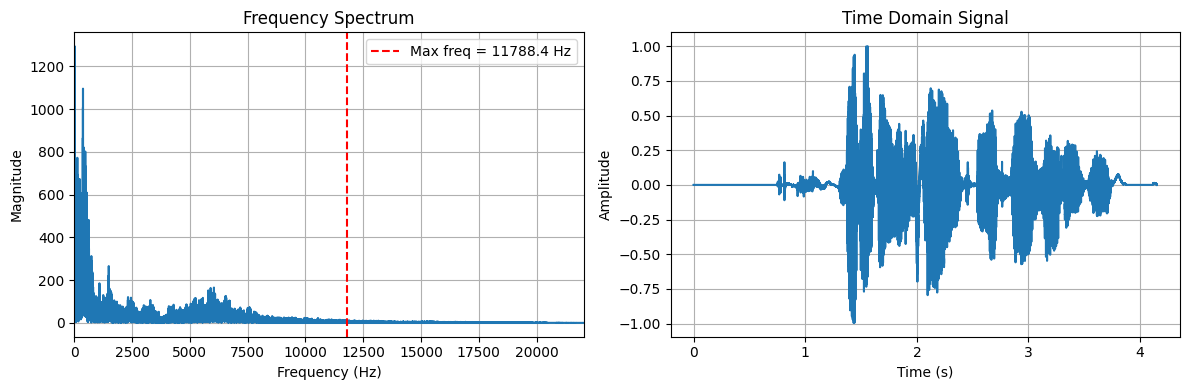

Determined maximum significant frequency: 11788.43 Hz


In [5]:
def determine_max_frequency(sig: np.ndarray, sr: int, threshold_ratio: float = 0.01) -> float:
    n = len(sig)
    yf = fft(sig)
    xf = fftfreq(n, 1/sr)
    pos_idx = xf >= 0
    xf_pos = xf[pos_idx]
    yf_pos = np.abs(yf[pos_idx])
    thresh = threshold_ratio * np.max(yf_pos)
    significant = xf_pos[yf_pos > thresh]
    max_freq = float(np.max(significant)) if significant.size > 0 else 4000.0

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(xf_pos, yf_pos)
    plt.axvline(max_freq, color='r', linestyle='--', label=f'Max freq = {max_freq:.1f} Hz')
    plt.xlim(0, min(sr/2, max_freq*2 + 500))
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.title('Frequency Spectrum')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    t = np.arange(len(sig))/sr
    plt.plot(t, sig)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title('Time Domain Signal')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Determined maximum significant frequency: {max_freq:.2f} Hz")
    return max_freq

max_frequency = determine_max_frequency(original_signal, sample_rate)


In [6]:
from typing import Tuple, Dict, Any

def calculate_sampling_rates(max_freq: float) -> Dict[str,int]:
    nyquist = 2 * max_freq
    appropriate = max(8000, int(nyquist * 1.5))
    sampling_rates = {
        'undersampled': max(4000, int(nyquist * 0.8)),
        'nyquist': int(np.ceil(nyquist)),
        'appropriate': int(appropriate),
        'oversampled': 44100
    }
    print(f"Nyquist rate (2*max_freq) = {nyquist:.2f} Hz")
    print("Sampling rates to test:", sampling_rates)
    return sampling_rates

sampling_rates = calculate_sampling_rates(max_frequency)


Nyquist rate (2*max_freq) = 23576.87 Hz
Sampling rates to test: {'undersampled': 18861, 'nyquist': 23577, 'appropriate': 35365, 'oversampled': 44100}


In [7]:
def reconstruct_signal(sig: np.ndarray, orig_sr: int, target_rate: int) -> Tuple[np.ndarray,int]:
    if target_rate == orig_sr:
        return sig, orig_sr
    num_samples = int(len(sig) * target_rate / orig_sr)
    reconstructed = signal.resample(sig, num_samples)
    return reconstructed, target_rate

def evaluate_reconstruction_quality(original: np.ndarray, reconstructed: np.ndarray) -> Dict[str,Any]:
    # Resample reconstructed to original length to compare
    if len(reconstructed) != len(original):
        reconstructed_resampled = signal.resample(reconstructed, len(original))
    else:
        reconstructed_resampled = reconstructed.copy()

    eps = 1e-12
    noise = original - reconstructed_resampled
    signal_power = np.mean(original**2) + eps
    noise_power = np.mean(noise**2) + eps
    snr_db = 10 * np.log10(signal_power / noise_power)
    mse = np.mean((original - reconstructed_resampled)**2)
    corr = np.corrcoef(original, reconstructed_resampled)[0,1]
    return {'snr_db': float(snr_db), 'mse': float(mse), 'correlation': float(corr)}

quality_metrics = {}
reconstructed_signals = {}

for name, rate in sampling_rates.items():
    print(f"\nTesting {name} ({rate} Hz)...")
    recon_sig, recon_sr = reconstruct_signal(original_signal, sample_rate, rate)
    metrics = evaluate_reconstruction_quality(original_signal, recon_sig)
    metrics['sampling_rate'] = recon_sr
    quality_metrics[name] = metrics
    reconstructed_signals[name] = (recon_sig, recon_sr)
    print(f"  SNR: {metrics['snr_db']:.2f} dB, MSE: {metrics['mse']:.6e}, Corr: {metrics['correlation']:.4f}")



Testing undersampled (18861 Hz)...
  SNR: 26.42 dB, MSE: 4.225277e-05, Corr: 0.9989

Testing nyquist (23577 Hz)...
  SNR: 31.76 dB, MSE: 1.235279e-05, Corr: 0.9997

Testing appropriate (35365 Hz)...
  SNR: 47.53 dB, MSE: 3.273662e-07, Corr: 1.0000

Testing oversampled (44100 Hz)...
  SNR: 102.68 dB, MSE: 0.000000e+00, Corr: 1.0000


In [8]:
# Choose best by SNR then correlation
best_name = max(quality_metrics.items(), key=lambda x: (x[1]['snr_db'], x[1]['correlation']))[0]
best_sig, best_sr = reconstructed_signals[best_name]
out_file = "best_reconstructed_signal.wav"
sf.write(out_file, best_sig, best_sr)
print(f"Best reconstruction: {best_name} ({best_sr} Hz), saved as {out_file}")


Best reconstruction: oversampled (44100 Hz), saved as best_reconstructed_signal.wav


In [9]:
from IPython.display import Audio, display

print("Playing the best reconstructed signal:")
display(Audio(out_file))

Playing the best reconstructed signal:
